# Interpret the Final Average

In this notebook, we take the output final spectrum from the `average-over-days` notebook, and interpret it with the cosmological model.

In [1]:
avgspec_file: str = "averaged_spectrum.gsh5"
DATA = "/data7/smurray/edges/projects_with_nive/edges-bowman2018-pipeline/input-data"

In [2]:
# Parameters
avgspec_file = "/data7/smurray/edges/projects_with_nive/edges-bowman2018-pipeline/work/d2/fe89a507ae26d9486bb63009b7a970/averaged_spectrum.gsh5"


## Imports and Data Loading

In [3]:
from pathlib import Path
from pygsdata import GSData
import numpy as np
import matplotlib.pyplot as plt

from edges import modeling as mdl
from edges.inference import SemiLinearFit, FlattenedGaussian


In [4]:
DATA = Path(DATA)

In [5]:
data = GSData.from_file(avgspec_file)

In [6]:
mask = data.flagged_nsamples[0,0,0]>0

In [7]:
eor_model = FlattenedGaussian(
    params={
        'amp': {'min': 0, 'max': 1.0, 'fiducial': 0.5}, 
        'tau': {'min': 0.1, 'max': 30, 'fiducial': 0.1}, 
        'w': {'min': 3, 'max': 25, 'fiducial': 17.0}, 
        'nu0': {'min': 50, 'max': 100, 'fiducial': 75.0}
    }, 
    freqs=data.freqs.to_value("MHz")[mask]
)

In [8]:
alan = np.genfromtxt("/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData/final_average_2024-10-02_01-18.txt", usecols=(1, 3, 6, 9, 12), names=('freq', 'tant', 'model', 'resid', 'weight'))

In [9]:
alan2 = np.genfromtxt(
    "/home/smurray/data4/edges/alans-pipeline/results/H2-final-average.csv",
    skip_header=1, names=['freq', 'weight', 'tsky', 'tres1', 'tres2', 'tmodel', 't21'], delimiter=','
)

In [10]:
sf = SemiLinearFit(
    fg=mdl.PhysicalLin(n_terms=5).at(x=data.freqs.to_value("MHz")[mask]), 
    eor=eor_model, 
    spectrum=data.data[0,0,0,mask], 
    sigma=0.3
)

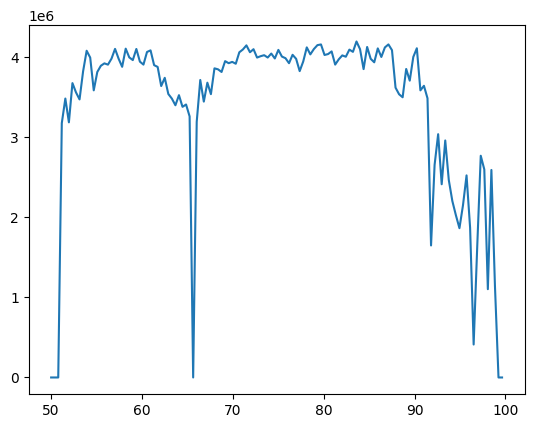

In [11]:
plt.plot(data.freqs, data.flagged_nsamples[0,0,0])

In [12]:
sf_weighted = SemiLinearFit(
    fg=mdl.PhysicalLin(n_terms=5).at(x=data.freqs.to_value("MHz")[mask]), 
    eor=eor_model, 
    spectrum=data.data[0,0,0,mask], 
    sigma= 0.3 * (data.freqs[mask].to_value("MHz")/75.0)**-2.55 / data.flagged_nsamples[0,0,0,mask]
)

In [13]:
sffit = sf()

In [14]:
sffit_weighted = sf_weighted()

In [15]:
print(sffit.x)
print(sffit_weighted.x)

[ 0.5523892   6.67715104 18.75182653 78.3188346 ]
[ 0.52490836  6.55772873 18.69571803 78.21637806]


In [16]:
alan = np.genfromtxt("/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData/final_average_latest.txt",  usecols=(1, 3, 6, 9, 12), names=('freq', 'tant', 'model', 'resid', 'weight'))

In [17]:
orig = np.genfromtxt(DATA / "figure1_plotdata.csv",  delimiter=',', skip_header=1)

In [18]:
sffit.success, sffit_weighted.success

(True, True)

In [19]:
sfal = SemiLinearFit(
    fg=mdl.PhysicalLin(n_terms=5).at(x=data.freqs.to_value("MHz")[mask]), 
    eor=eor_model, 
    spectrum=alan['tant'][mask], 
    sigma=0.3
)
sfalfit = sfal()

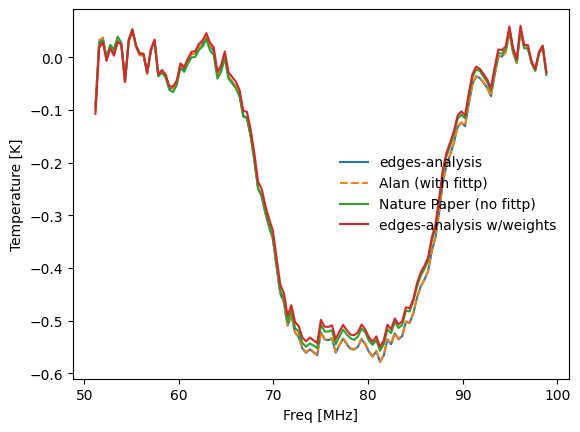

In [20]:
plt.plot(data.freqs[mask], sf.get_eor(sffit.x) + sf.get_resid(sffit.x), label='edges-analysis')
plt.plot(data.freqs[mask], sfal.get_eor(sfalfit.x) + sfal.get_resid(sfalfit.x), label='Alan (with fittp)', ls='--')
plt.plot(data.freqs[mask], orig[mask, -1], label='Nature Paper (no fittp)')
plt.plot(data.freqs[mask], sf_weighted.get_eor(sffit_weighted.x) + sf_weighted.get_resid(sffit_weighted.x), label='edges-analysis w/weights')

plt.xlabel("Freq [MHz]")
plt.ylabel("Temperature [K]")
plt.legend(frameon=False)